In [21]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
df_raw = pd.read_csv("../data/DSA4262 Phone Use Survey.csv")

# Converting to Numerical values 

In [23]:
# Mapping of original question text to concise column names
question_map = {
    "Timestamp": "Timestamp",
    "Age": "Q1_Age",
    "Gender": "Q2_Gender",
    "Occupational / Educational Status": "Q3_Status",
    "On average, how much time did you spend using your smartphone per day in the last 2 weeks?": "Q4_DailyPhoneTime",
    "How often do you check your phone in a typical day? (estimate)": "Q5_CheckFrequency",
    "How soon do you usually check your phone after waking up?": "Q6_AfterWakeCheck",
    "How often do you use your phone after 11 PM?": "Q7_After11PMUse",
    "When do you usually stop using your phone at night?": "Q8_StopUseAtNight",
    "Which categories of apps do you use the most?": "Q9_TopAppCategories",
    "Approximately how much time per day do you spend on social media apps?": "Q10_SocialMediaTime",
    "I use my phone during meals.": "Q11_PhoneDuringMeals",
    "I use my phone during lectures, meetings, or work.": "Q12_PhoneDuringWorkClass",
    "I check my phone while studying or working on tasks.": "Q13_CheckDuringTasks",
    "Notifications interrupt my work or concentration.": "Q14_NotificationsInterrupt",
    "I use my phone when I feel bored.": "Q15_UseWhenBored",
    "I use my phone when I feel stressed.": "Q16_UseWhenStressed",
    "I use my phone to distract myself from negative emotions.": "Q17_DistractNegativeEmotions",
    "I use my phone in bed before going to sleep.": "Q18_PhoneInBed",
    "Phone use delays the time I go to sleep.": "Q19_PhoneDelaysSleep",
    "Notifications wake me up at night.": "Q20_NotificationsWakeNight",
    "I wake up during the night to check my phone.": "Q21_WakeToCheckPhone",
    "I unlock my phone without a clear reason.": "Q22_UnlockWithoutReason",
    "I continue using my phone longer than I intended.": "Q23_UseLongerThanIntended_A",
    "I try to reduce my phone use but fail.": "Q24_FailToReduceUse",
    "I miss planned work due to smartphone use.": "Q25_MissPlannedWork",
    "I have a hard time concentrating in class, while doing assignments, or while working due to smartphone use.": "Q26_ConcentrationProblems",
    "I feel pain in my wrists or at the back of my neck while using a smartphone.": "Q27_PhysicalPain",
    "I wouldn’t be able to stand not having a smartphone.": "Q28_CannotStandWithoutPhone",
    "I feel impatient and fretful when I am not holding my smartphone.": "Q29_ImpatientWithoutPhone",
    "I have my smartphone in my mind even when I am not using it.": "Q30_PhoneOnMyMind",
    "I will never give up using my smartphone even when my daily life is affected by it.": "Q31_WontGiveUpPhone",
    "I constantly check my smartphone so as not to miss conversations or notifications.": "Q32_ConstantChecking",
    "I use my smartphone longer than I had intended.": "Q33_UseLongerThanIntended_B",
    "People around me tell me that I use my smartphone too much.": "Q34_OthersSayTooMuchUse",
    "Little interest or pleasure in doing things.": "Q35_PHQ1_Interest",
    "Feeling down, depressed, or hopeless.": "Q36_PHQ2_Down",
    "Trouble falling or staying asleep, or sleeping too much.": "Q37_PHQ3_Sleep",
    "Feeling tired or having little energy.": "Q38_PHQ4_Tired",
    "Poor appetite or overeating.": "Q39_PHQ5_Appetite",
    "Feeling bad about yourself — or that you are a failure or have let yourself or your family down.": "Q40_PHQ6_SelfWorth",
    "Trouble concentrating on things, such as reading or watching television.": "Q41_PHQ7_Concentration",
    "Moving or speaking so slowly that other people could have noticed, or the opposite — being fidgety or restless.": "Q42_PHQ8_RestlessSlow",
    "Thoughts that you would be better off dead or of hurting yourself in some way.": "Q43_PHQ9_SelfHarm"
}

df_named = df_raw.rename(columns=question_map)

In [24]:
# Mapping of categorical responses to numerical values for analysis
time_map = {
    "Less than 2 hours": 1,
    "2 to 4 hours": 2,
    "4 to 6 hours": 3,
    "6 to 8 hours": 4,
    "More than 8 hours": 5
}

check_freq_map = {
    "Less than 20": 1,
    "20 to 50": 2,
    "50 to 100": 3,
    "More than 100": 4
}

wake_check_map = {
    "Immediately": 1,
    "Within 5 minutes": 2,
    "5 to 30 minutes": 3,
    "More than 30 minutes": 4
}

late_night_map = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Almost every night": 5
}

stop_time_map = {
    "Before 10pm": 1,
    "10pm to 11pm": 2,
    "11pm to 12am": 3,
    "12am to 1am": 4,
    "After 1am": 5
}

social_media_time_map = {
    "Less than 30 minutes": 1,
    "30 to 60 minutes": 2,
    "1 to 2 hours": 3,
    "2 to 4 hours": 4,
    "More than 4 hours": 5
}

freq_map = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Always": 5
}

agree_map = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Weakly disagree": 3,
    "Weakly agree": 4,
    "Agree": 5,
    "Strongly agree": 6
}

phq_map = {
    "Not at all": 0,
    "Several days": 1,
    "More than half the days": 2,
    "Nearly every day": 3
}

In [25]:
df_model = df_named.copy()

# Ordinal usage behaviour
df_model["Q4_DailyPhoneTime_num"] = df_model["Q4_DailyPhoneTime"].map(time_map)
df_model["Q5_CheckFrequency_num"] = df_model["Q5_CheckFrequency"].map(check_freq_map)
df_model["Q6_AfterWakeCheck_num"] = df_model["Q6_AfterWakeCheck"].map(wake_check_map)
df_model["Q7_After11PMUse_num"] = df_model["Q7_After11PMUse"].map(late_night_map)
df_model["Q8_StopUseAtNight_num"] = df_model["Q8_StopUseAtNight"].map(stop_time_map)
df_model["Q10_SocialMediaTime_num"] = df_model["Q10_SocialMediaTime"].map(social_media_time_map)

# Frequency-style Likert
freq_cols = [
    "Q11_PhoneDuringMeals", "Q12_PhoneDuringWorkClass", "Q13_CheckDuringTasks",
    "Q14_NotificationsInterrupt", "Q15_UseWhenBored", "Q16_UseWhenStressed",
    "Q17_DistractNegativeEmotions", "Q18_PhoneInBed", "Q19_PhoneDelaysSleep",
    "Q20_NotificationsWakeNight", "Q21_WakeToCheckPhone", "Q22_UnlockWithoutReason",
    "Q23_UseLongerThanIntended_A", "Q24_FailToReduceUse"
]

for col in freq_cols:
    df_model[col + "_num"] = df_model[col].map(freq_map)

# Agreement-style Likert
agree_cols = [
    "Q25_MissPlannedWork", "Q26_ConcentrationProblems", "Q27_PhysicalPain",
    "Q28_CannotStandWithoutPhone", "Q29_ImpatientWithoutPhone", "Q30_PhoneOnMyMind",
    "Q31_WontGiveUpPhone", "Q32_ConstantChecking", "Q33_UseLongerThanIntended_B",
    "Q34_OthersSayTooMuchUse"
]

for col in agree_cols:
    df_model[col + "_num"] = df_model[col].map(agree_map)

# PHQ-9
phq_cols = [
    "Q35_PHQ1_Interest", "Q36_PHQ2_Down", "Q37_PHQ3_Sleep",
    "Q38_PHQ4_Tired", "Q39_PHQ5_Appetite", "Q40_PHQ6_SelfWorth",
    "Q41_PHQ7_Concentration", "Q42_PHQ8_RestlessSlow", "Q43_PHQ9_SelfHarm"
]

for col in phq_cols:
    df_model[col + "_num"] = df_model[col].map(phq_map)

df_model["PHQ9_Total"] = df_model[[c + "_num" for c in phq_cols]].sum(axis=1)
df_model["PHQ9_10plus"] = (df_model["PHQ9_Total"] >= 10).astype(int)

# One hot encoding

In [26]:
# One-hot encode categorical variables
df_model = pd.get_dummies(
    df_model,
    columns=["Q2_Gender", "Q3_Status"],
    drop_first=False
)

In [27]:
# Split top app categories into separate binary columns
app_categories = [
    "Social media",
    "Messaging",
    "Productivity or study",
    "Web browsing",
    "Video or streaming",
    "Gaming",
    "Shopping"
]

df_model["Q9_App_SocialMedia"] = df_model["Q9_TopAppCategories"].fillna("").apply(lambda x: int("Social media" in x))
df_model["Q9_App_Messaging"] = df_model["Q9_TopAppCategories"].fillna("").apply(lambda x: int("Messaging" in x))
df_model["Q9_App_ProductivityStudy"] = df_model["Q9_TopAppCategories"].fillna("").apply(lambda x: int("Productivity or study" in x))
df_model["Q9_App_WebBrowsing"] = df_model["Q9_TopAppCategories"].fillna("").apply(lambda x: int("Web browsing" in x))
df_model["Q9_App_VideoStreaming"] = df_model["Q9_TopAppCategories"].fillna("").apply(lambda x: int("Video or streaming" in x))
df_model["Q9_App_Gaming"] = df_model["Q9_TopAppCategories"].fillna("").apply(lambda x: int("Gaming" in x))
df_model["Q9_App_Shopping"] = df_model["Q9_TopAppCategories"].fillna("").apply(lambda x: int("Shopping" in x))

In [28]:
df_model.head()


,Timestamp,Q1_Age,Q4_DailyPhoneTime,Q5_CheckFrequency,Q6_AfterWakeCheck,Q7_After11PMUse,Q8_StopUseAtNight,Q9_TopAppCategories,Q10_SocialMediaTime,Q11_PhoneDuringMeals,...,Q3_Status_Employed,Q3_Status_Student,Q3_Status_Unemployed,Q9_App_SocialMedia,Q9_App_Messaging,Q9_App_ProductivityStudy,Q9_App_WebBrowsing,Q9_App_VideoStreaming,Q9_App_Gaming,Q9_App_Shopping
0,15/03/2026 19:26:41,24.0,2 to 4 hours,20 to 50,Within 5 minutes,Sometimes,11pm to 12am,"Messaging, Productivity or study, Web browsing",Less than 30 minutes,Often,...,False,True,False,0,1,1,1,0,0,0
1,15/03/2026 19:39:00,25.0,6 to 8 hours,More than 100,Immediately,Almost every night,After 1am,"Social media, Video or streaming, Gaming",2 to 4 hours,Always,...,False,True,False,1,0,0,0,1,1,0
2,15/03/2026 19:48:22,26.0,4 to 6 hours,20 to 50,Within 5 minutes,Rarely,10pm to 11pm,Social media,2 to 4 hours,Sometimes,...,True,False,False,1,0,0,0,0,0,0
3,15/03/2026 19:48:31,24.0,6 to 8 hours,20 to 50,Immediately,Often,12am to 1am,"Social media, Messaging, Video or streaming",More than 4 hours,Often,...,True,False,False,1,1,0,0,1,0,0
4,15/03/2026 19:50:08,24.0,More than 8 hours,50 to 100,Immediately,Almost every night,After 1am,"Social media, Video or streaming, Web browsing",2 to 4 hours,Always,...,False,True,False,1,0,0,1,1,0,0


In [29]:
# count number of NAs total
total_nas = df_model.isna().sum().sum()
print(f"Total number of NAs in the processed DataFrame: {total_nas}")

Total number of NAs in the processed DataFrame: 0


In [30]:
# Save the processed DataFrame for modeling
df_model.to_csv("../data/DSA4262_Survey_Cleaned.csv", index=False)

Text(0.5, 1.0, 'Distribution of PHQ-9 Total Scores')

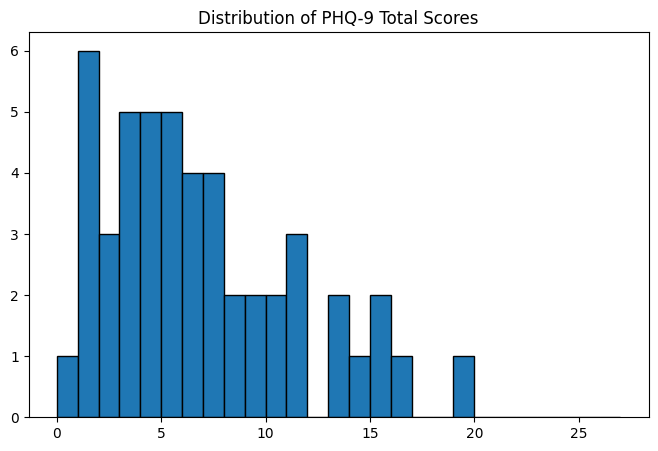

In [ ]:
# plot distribution of PHQ-9 total scores
plt.figure(figsize=(8, 5))
plt.hist(df_model["PHQ9_Total"], bins=range(0, 28), edgecolor='black')
plt.title("Distribution of PHQ-9 Total Scores")

In [32]:
# PHQ-9 Score Interpretation
# 0-4: Minimal depression
# 5-9: Mild depression
# 10-14: Moderate depression
# 15-19: Moderately severe depression
# 20-27: Severe depression

# count number of participants in each PHQ-9 severity category
phq_bins = [0, 4, 9, 14, 19, 27]
phq_labels = ["Minimal", "Mild", "Moderate", "Moderately Severe", "Severe"]
df_model["PHQ9_Severity"] = pd.cut(df_model["PHQ9_Total"], bins=phq_bins, labels=phq_labels, right=True)
severity_counts = df_model["PHQ9_Severity"].value_counts().sort_index()
print("PHQ-9 Severity Category Counts:")
print(severity_counts)

PHQ-9 Severity Category Counts:
PHQ9_Severity
Minimal              19
Mild                 17
Moderate              8
Moderately Severe     4
Severe                0
Name: count, dtype: int64
